# Tutorial 03: Hyperparameter Search

Choosing a good learning rate, model size, or optimizer by hand is tedious. Talos Alchemy automates this with a clean two-step API:

1. **Define a search space** — specify which hyperparameters to tune and their ranges
2. **Run a search** — pass an objective function and get back the best configuration

This tutorial demonstrates all three built-in strategies:

| Strategy | How it samples | Best for |
|---|---|---|
| `RandomSearch` | Uniform random | Quick baselines |
| `GridSearch` | Exhaustive grid | Small discrete spaces |
| `BayesianSearch` | TPE (learns from past trials) | Expensive objectives |

We'll use the same $\sin(x)$ regression task from the previous tutorials.

### Step 0: Setups
---

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils import add_necessary_paths, check_torch
add_necessary_paths()

import utils.u03 as u
import talos as ta
from talos.optim.alchemy import (
  RandomSearch, GridSearch, BayesianSearch,
  ContinuousParam, IntParam,
)
import numpy as np

check_torch()
ta.set_seed()

 ! Cannot determine main file path in interactive mode.
:: PyTorch version: 2.6.0+cu124
:: CUDA is available. Number of CUDA devices: 7


DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "/pytorch/aten/src/ATen/cuda/CUDAContext.cpp":49, please report a bug to PyTorch. device=6, num_gpus=

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/sbh/miniconda3/env

### Step 1: Define the objective function
---

An **objective function** encapsulates everything: data loading, model construction, training, and evaluation. It receives a `params` dict and returns a scalar score. Alchemy calls it once per trial — you own the details inside.

In [3]:
# Shared data — same for every trial to keep comparisons fair
X, Y = u.generate_data(n=200, noise=0.15, seed=0)
dataset   = ta.Dataset(X, Y)
train_set, val_set = dataset.split(4, 1, shuffle=True)

In [4]:
def objective(params):
  """Build, train, and evaluate a model for the given hyperparameters.

  Args:
    params: dict with keys 'lr' and 'hidden_size'.

  Returns:
    Best validation MSE (lower is better).
  """
  lr          = params['lr']
  hidden_size = params['hidden_size']

  # (1) Build model with the suggested hidden size.
  model   = ta.model.torch_zoo.MLP(1, [hidden_size, hidden_size], 1,
                                   activation='tanh')
  trainer = u.get_trainer(model, lr=lr, print_every=99999)

  # (2) Train with early stopping.
  trainer.config.validate_every = 100
  trainer.config.early_stop     = True
  trainer.config.patience        = 10
  trainer.train(train_set, val_set=val_set, val_metrics=['mse'],
                max_iterations=2000)

  # (3) Return the best validation MSE achieved.
  _, best_val = trainer.history.best('val/mse')
  return best_val

### Step 2: Define the search space
---

The **search space** is a dict mapping parameter names to `Param` objects. Each `Param` type tells the strategy how to sample that axis:

- `ContinuousParam(low, high, log=True)` — continuous range, optionally log-scaled
- `IntParam(low, high)` — integer range (inclusive)
- `CategoricalParam(choices)` — fixed set of options

In [5]:
# Define the search space
space = {
  'lr':          ContinuousParam(1e-4, 1e-1, log=True),  # log scale: 0.0001 to 0.1
  'hidden_size': IntParam(8, 64),                          # 8 to 64 units
}

### Step 3: Random search
---

`RandomSearch` samples hyperparameters uniformly at random. It's the simplest strategy and a good baseline — for a small budget, it often finds a competitive configuration faster than grid search.

In [6]:
# Run random search with 15 trials
random_history = RandomSearch().run(objective, space, n_trials=15)
print('Random search best score:  ', random_history.best_score)
print('Random search best params: ', random_history.best_params)

/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>> Search started (n_trials=15)
[talos.pytorch] torch=2.6.0+cu124; cuda=yes (v12.4); GPU 7/7="cuda:0"
>> Training started (max_iterations=2000)
.. val/mse = 0.0695668
.. [Best] val/mse = 0.0695668 (iter 100)
.. val/mse = 0.057743
.. [Best] val/mse = 0.057743 (iter 200)
.. val/mse = 0.0375536
.. [Best] val/mse = 0.0375536 (iter 300)
.. val/mse = 0.0282803
.. [Best] val/mse = 0.0282803 (iter 400)
.. val/mse = 0.0278338
.. [Best] val/mse = 0.0278338 (iter 500)
.. val/mse = 0.0286578
.. val/mse = 0.0295917
.. val/mse = 0.0296455
.. val/mse = 0.0298261
.. val/mse = 0.0299652
.. val/mse = 0.0299346
.. val/mse = 0.0299511
.. val/mse = 0.0299461
.. val/mse = 0.0300174
.. val/mse = 0.0299109
>> Restored best model (iter 500, val/mse = 0.0278338)
>> Early stopping at iter 1500 (patience=10)
>> Trial 1/15: {'lr': 0.0018663018711448053, 'hidden_size': 52}
.. score = 0.0278338
>> Training started (max_iterations=2000)
.. val/mse = 0.0714845
.. [Best] val/mse = 0.0714845 (iter 100)
.. val/mse = 0.05

### Step 4: Grid search
---

`GridSearch` exhaustively evaluates all combinations of a discretized grid. The grid resolution is controlled by `n_points` for continuous/integer axes, while categorical axes enumerate all choices.

In [7]:
# Grid search: 4 lr values × 4 hidden_size values = 16 trials
gs = GridSearch()
gs.config.n_points = 4

grid_history = gs.run(objective, space)
print('Grid search best score:  ', grid_history.best_score)
print('Grid search best params: ', grid_history.best_params)

>> Search started (n_trials=20)
>> Training started (max_iterations=2000)
.. val/mse = 0.222115
.. [Best] val/mse = 0.222115 (iter 100)
.. val/mse = 0.134326
.. [Best] val/mse = 0.134326 (iter 200)
.. val/mse = 0.104335
.. [Best] val/mse = 0.104335 (iter 300)
.. val/mse = 0.0727423
.. [Best] val/mse = 0.0727423 (iter 400)
.. val/mse = 0.0592079
.. [Best] val/mse = 0.0592079 (iter 500)
.. val/mse = 0.0531885
.. [Best] val/mse = 0.0531885 (iter 600)
.. val/mse = 0.0468954
.. [Best] val/mse = 0.0468954 (iter 700)
.. val/mse = 0.0403857
.. [Best] val/mse = 0.0403857 (iter 800)
.. val/mse = 0.0347836
.. [Best] val/mse = 0.0347836 (iter 900)
.. val/mse = 0.030905
.. [Best] val/mse = 0.030905 (iter 1000)
.. val/mse = 0.0286912
.. [Best] val/mse = 0.0286912 (iter 1100)
.. val/mse = 0.0277535
.. [Best] val/mse = 0.0277535 (iter 1200)
.. val/mse = 0.0275485
.. [Best] val/mse = 0.0275485 (iter 1300)
.. val/mse = 0.0277325
.. val/mse = 0.027993
.. val/mse = 0.0283345
.. val/mse = 0.0286572
.. val/

### Step 5: Bayesian search
---

`BayesianSearch` uses a Tree-structured Parzen Estimator (TPE) to build a probabilistic model of the objective surface. After an initial random phase (`n_initial` trials), it actively proposes configurations most likely to improve the current best — making it efficient for expensive objective functions.

In [8]:
# Bayesian search: 5 random bootstrap trials, then TPE-guided
bs = BayesianSearch()
bs.config.n_initial = 5

bayes_history = bs.run(objective, space, n_trials=20)
print('Bayesian search best score:  ', bayes_history.best_score)
print('Bayesian search best params: ', bayes_history.best_params)

>> Search started (n_trials=20)
>> Training started (max_iterations=2000)
.. val/mse = 0.431145
.. [Best] val/mse = 0.431145 (iter 100)
.. val/mse = 0.290875
.. [Best] val/mse = 0.290875 (iter 200)
.. val/mse = 0.20873
.. [Best] val/mse = 0.20873 (iter 300)
.. val/mse = 0.171871
.. [Best] val/mse = 0.171871 (iter 400)
.. val/mse = 0.150506
.. [Best] val/mse = 0.150506 (iter 500)
.. val/mse = 0.133857
.. [Best] val/mse = 0.133857 (iter 600)
.. val/mse = 0.120433
.. [Best] val/mse = 0.120433 (iter 700)
.. val/mse = 0.109887
.. [Best] val/mse = 0.109887 (iter 800)
.. val/mse = 0.101837
.. [Best] val/mse = 0.101837 (iter 900)
.. val/mse = 0.0957657
.. [Best] val/mse = 0.0957657 (iter 1000)
.. val/mse = 0.0911445
.. [Best] val/mse = 0.0911445 (iter 1100)
.. val/mse = 0.0875345
.. [Best] val/mse = 0.0875345 (iter 1200)
.. val/mse = 0.0846027
.. [Best] val/mse = 0.0846027 (iter 1300)
.. val/mse = 0.0821
.. [Best] val/mse = 0.0821 (iter 1400)
.. val/mse = 0.0798382
.. [Best] val/mse = 0.079838

### Step 6: Compare strategies
---

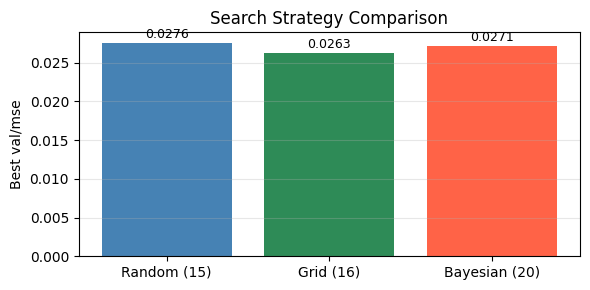

In [9]:
# Side-by-side comparison of best scores
results = {
  'Random (15)':   random_history.best_score,
  'Grid (16)':     grid_history.best_score,
  'Bayesian (20)': bayes_history.best_score,
}
u.plot_search_comparison(results)

### Takeaway

All three strategies share the same two-line API:

```python
space = {'lr': ContinuousParam(1e-4, 1e-1, log=True), 'hidden_size': IntParam(8, 64)}

history = RandomSearch().run(objective, space, n_trials=20)
print(history.best_params)
print(history.best_score)
```

**When to use each strategy:**

- `RandomSearch` — fast baseline; good when the budget is very small
- `GridSearch` — when you want guarantees that the full parameter space is covered (small discrete spaces)
- `BayesianSearch` — when each trial is expensive and you want to squeeze the most from a limited budget

The objective function is completely under your control — Alchemy only sees the scalar score you return. This makes it trivial to plug in cross-validation, multi-metric objectives, or any custom training loop.